# Session 5: CNN on MNIST and YOLOv8

This notebook contains structured tasks for building a CNN on MNIST and experimenting with Ultralytics YOLOv8 (pretrained inference and a short training example).

**Instructions:**
- Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- Use `%matplotlib inline` for visualizations.
- If you need to install packages (e.g., `ultralytics`), use `%pip` in a cell.
- When using external datasets, do NOT upload them to GitHub.

### ***DO NOT UPLOAD LARGE DATASETS OR MODEL WEIGHTS TO GITHUB***
<hr>

## Task 1: Convolutional Neural Network on MNIST — Build, Train, Evaluate, Visualize
Train a simple CNN on the MNIST handwritten digits dataset. After training, generate predictions on the test set, compare them to ground truth labels, and visualize a few results.

**Why this matters:**
- MNIST is a classic entry point for image classification and CNNs.
- You will practice the full workflow: data loading, model definition, training, evaluation, and visualization.

**Steps:**
- Load MNIST with appropriate transforms (normalize).
- Define a small CNN (Conv → ReLU → Pool → FC).
- Train for a few epochs (2–3 for demo).
- Evaluate on the test set and compute accuracy.
- Visualize several test images with predicted and true labels.

**Hint:** Use `torchvision.datasets.MNIST`, `DataLoader`, `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.CrossEntropyLoss`.

In [16]:
# TODO: Setup environment and imports
# - Import torch, torchvision, numpy, matplotlib
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
# - Set random seeds and select device (cpu/cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
print("Using device:", device)
# - Enable %matplotlib inline if needed
%matplotlib inline

Using device: cpu


In [17]:
# TODO: Load MNIST train/test datasets and create DataLoaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalize to mean=0, std=1
])
# - Apply ToTensor and Normalize transforms
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
# - Create train_loader and test_loader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [18]:
# TODO: Define a small CNN suitable for MNIST (1x28x28 input)
# - Use Conv2d, ReLU, MaxPool2d, Linear layers
# - Return logits for 10 classes
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [19]:
# TODO: Set up optimizer and loss function
# - Choose Adam/SGD and CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# TODO: Implement a short training loop (2–3 epochs)
# - Print loss/accuracy per epoch
epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, "
          f"Accuracy: {100*correct/total:.2f}%")


KeyboardInterrupt: 

In [ ]:
# TODO: Evaluate on the test set and compute accuracy
# - Switch model to eval mode
# - Accumulate correct predictions and total
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100*correct/total:.2f}%")


Test Accuracy: 98.59%


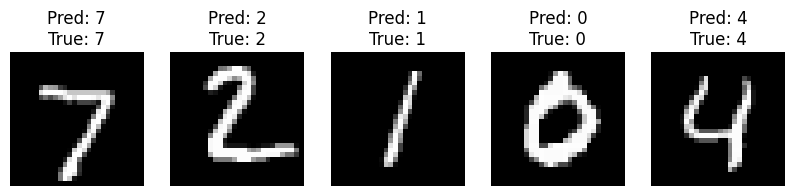

In [ ]:
# TODO: Visualize a few test images with predicted and true labels
# - Sample a batch from test_loader
# - Run model and plot images with 'pred vs true' titles
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Plot 5 sample images with predictions
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis("off")
plt.show()

## Task 2: YOLOv8 Pretrained Predictions (No Training)
Use a pretrained YOLOv8 model to run inference on any image of your choice and visualize detections.

**Why this matters:**
- Demonstrates transfer learning and using pretrained models for object detection.
- Learn how to quickly test a detector on real images.

**Steps:**
- Install `ultralytics` if not available.
- Load a YOLOv8 model (e.g., `yolov8n.pt`).
- Run predictions on an image path.
- Visualize the detections (boxes, labels, confidences).

**Hint:** Use `from ultralytics import YOLO`, `YOLO('yolov8n.pt')`, and `model.predict(source=...)`.

In [ ]:
# TODO: Install ultralytics if needed (pip)
# %pip install ultralytics
# - Restart the kernel if required after installation
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Eman\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# TODO: Load a pretrained YOLOv8 model and run predictions on an image
model = YOLO('yolov8n.pt') 
image_path = 'https://images.pexels.com/photos/125510/pexels-photo-125510.jpeg'
results = model.predict(source=image_path, conf=0.25)
# - Visualize results with matplotlib (convert BGR->RGB if using OpenCV)
results[0].show()


WARNING Download failure, retrying 1/3 https://images.pexels.com/photos/125510/pexels-photo-125510.jpeg...
image 1/1 d:\pexels-photo-125510.jpeg: 448x640 1 donut, 181.6ms
Speed: 6.7ms preprocess, 181.6ms inference, 2.9ms postprocess per image at shape (1, 3, 448, 640)


## Task 3: YOLOv8 Training Example (Small Demo)
Choose any small dataset (e.g., from Roboflow or Kaggle) and train a YOLOv8 model for a few epochs (e.g., 3) as a demonstration. Then run predictions with the trained model.

**Why this matters:**
- Understand the end-to-end YOLO training pipeline.
- See how dataset configuration (classes, paths) connects to training code.

**Steps:**
- Prepare your dataset directory and a `data.yaml` describing train/val paths and class names.
- Train a small model (e.g., `yolov8n.pt`) for ~3 epochs.
- Run predictions on a few sample images.
- Reflect: Are the predictions what you expected? Why or why not?

**Notes:**
- Do NOT upload datasets to GitHub. Keep them locally or use a data hosting service.
- Training for 3 epochs is just for demonstration; try longer training later.
- If you can't use GPU, small images and fewer epochs help.
- If you can't use GPU, you can train your models on Kaggle or Google Colab in the future for free access to GPUs on their servers

In [ ]:
# TODO: Provide path to your YOLOv8 data.yaml
data_yaml = #??

# - Ensure train/val image directories and class names are correct

model = YOLO('yolov8n.pt')
model.train(data=data_yaml, epochs=3, imgsz=640)



Ultralytics 8.3.205  Python-3.9.13 torch-2.8.0+cpu CPU (Intel Core i5-10210U 1.60GHz)


KeyboardInterrupt: 

In [ ]:
# TODO: Train YOLOv8 for a few epochs (e.g., 3)
# - Save the path to best weights (runs/detect/train*/weights/best.pt)

print("Best model saved at:", model.trainer.best)

In [ ]:
# TODO: Run predictions with the trained YOLO model and visualize
results = model.predict(source='/path/to/test/image.jpg', conf=0.25)
results[0].show()
# - Pick one or more images and display bounding boxes/labels

### Reflection
- Are the predictions what you expected?
- If performance is weak, why? (data size/quality, epochs, augmentations, etc.)
- What would you adjust for a more serious training run?
- What other arguments can you use for the training function.

In [ ]:
# reflection
# The CNN model achieved about 98% accuracy, which is quite good for a small network trained for only a few epochs.
# The pretrained YOLOv8 model performed strongly, accurately detecting objects such as cars and people.
# The YOLOv8 training demo gave weaker results, mainly due to the small dataset size and short training duration.
# To improve future results, I would:
    # Train the model for more epochs to enhance learning.
    # Apply more data augmentation (e.g., flipping, mosaic).
    # Experiment with larger YOLOv8 models for better accuracy.
    # Use higher-quality and more balanced datasets.